# Analyzing CRISPR screens with the Z-score method
Here we demonstrate the **Z-score method with empirical p-values** for the analysis of CRISPR screens with a unidimensional (i.e. viability) readout. This pipeline takes raw gDNA counts for each construct in a screen and identifies a false discovery rate for each gene to identify screening hits. This approach demonstrates the **core methodology implemented in the GPP Apron Tool** , although we emphasize that this code may not produce exact identical false discovery rates to Apron due to changes in rounding and minor modifications to Apron over time. 

We recommend starting by creating a virtual environment and downloading the necessary packages as described in the README of this repository. 

To analyze your data, you need input files that report...
1. Read counts associated with each construct across conditions
2. Genes targeted by each construct (often called “guide mappings”)
   
We recommend that you create a folder on your desktop and upload this data to that folder. Then, open the Terminal app and navigate to that folder. The easiest way to fill in the `path/to/folder` below is to drag the folder from your desktop or file explorer into terminal:
```
cd path/to/folder
```
Use the following command to open jupyter notebook

```
jupyter notebook 
```
This will open a tab in your web browser with the jupyter console. Create a notebook on this console by selecting `New > Python3 (ipykernel)`

Then follow the remaining steps in your jupyter notebook. 

#### Import necessary python packages

In [65]:
import pandas as pd
import numpy as np
import gpplot
import random
import scipy
from statsmodels.stats.multitest import multipletests

#### Load input files
Replace the filepath and name with the name of your read counts file.

In [66]:
readcount_filepath="6. Jacquere Screen Performance/Data/counts-STS_A375_A549_CP0081.txt"
readcounts=pd.read_table(readcount_filepath)
#optional: remove columns that will not be used 
readcounts=readcounts.drop(["Construct IDs","Unlabeled Sample Barcodes"],axis=1)
print("total # constructs:", len(readcounts))
readcounts.head()

total # constructs: 60550


,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B,CP0081 pDNA
0,AAAAAAGAAAGGATACGTCC,920,1448,1319,1254,437
1,AAAAACAGCTGATGAAACCT,681,804,1049,1383,390
2,AAAAACCTGGGAAAGATATA,1270,2073,2501,2248,480
3,AAAAAGAGGCGGCATTACAG,1224,1382,2850,2305,688
4,AAAAAGATAGATGTGCTAAA,92,296,236,258,521


Identify the name of columns to reference in the following analysis. In this example, we have two conditions to analyze separately: screens in the A375 or A549 cell line. If your screen only has one condition, you can arbitrarily pick one condition name for compatibility with the following code.

In [67]:
#From the counts file: 
#construct identifier column
constructname_col="Construct Barcode"
#reference condition column. for a viability screen, this is typically the pDNA counts of each construct
pDNA_col="CP0081 pDNA"
# identify the columns associated with each condition (i.e. here the column 'A375_CP0081_rep A' represents data from the A375 condition)
condition_map = {'A375_CP0081_rep A': 'A375',
                 'A375_CP0081_rep B': 'A375',
                 'A549_CP0081_rep A': 'A549',
                 'A549_CP0081_rep B': 'A549'}

Change the filepath below to read in your guide mappings

In [68]:
guidemappings_filepath="6. Jacquere Screen Performance/Data/Jacquere_PerGuideAnnotations.csv"
guidemappings=pd.read_csv(guidemappings_filepath)
guidemappings.head()

,sgRNA Sequence,Target Gene ID,Source,Target Gene Symbol,Other Target Matches,Target Transcript,Reference Sequence,Strand of sgRNA,sgRNA Cut Position (1-based),Exon Number,Aggregate CFD Score,Off-Target CFD100 Hits,Off-Target Tier I CFD100 Hits,On-Target Efficacy Score
0,GTAGTGACCTCCATCCCCCA,ENSG00000121410,GENCODE,A1BG,[],ENST00000263100.8,NC_000019.10,+,58351487,5,1.9481,0,0,1.138
1,ACTGGCGCCATCGAGAGCCA,ENSG00000121410,GENCODE,A1BG,['A1BG-AS1'],ENST00000263100.8,NC_000019.10,+,58352536,4,1.5,0,0,0.928
2,GTGGAGTGGACTTCCAGCTA,ENSG00000121410,GENCODE,A1BG,[],ENST00000263100.8,NC_000019.10,-,58351575,5,0.0,0,0,1.212
3,ATGACTCTCATACTCCACGA,ENSG00000148584,GENCODE,A1CF,[],ENST00000373997.8,NC_000010.11,+,50836128,6,0.7222,0,0,1.453
4,GAAGACAGGAGCTCCAAGGT,ENSG00000148584,GENCODE,A1CF,['ASAH2B'],ENST00000373997.8,NC_000010.11,+,50816123,9,0.0,0,0,1.039


Subset to only the columns that report the construct identifiers (which should match the read counts file) and target genes

In [69]:
guidemappings_constructname_col="sgRNA Sequence"
guidemappings_targetname_col="Target Gene Symbol"
guidemappings=guidemappings[[guidemappings_constructname_col,guidemappings_targetname_col]]

###  Log-normalize read counts
Due to differences between sequencing runs and sgRNA representation, we log-normalize the read counts. First, for each construct we take the number of reads divided by the total number of reads in a given condition. Since read counts tend to have a right skew, we also want to take the $\\log_2$ of these fractional abundances. Finally, since it is possible to have 0 reads and $\\log_2(0)$ is undefined, we multiply the fractional abundance by $1e6$ and add a pseudocount of 1 for our final equation
$$ \text{lognorm} = log2(\frac{{reads}}{{total\ reads\ in\ condition}} \times 1e6 + 1)$$

In [70]:
def lognorm(reads):
    """
    Standardize read counts by calculating reads per million,
    adding a pseudo-count of one, and taking the log2

    :param reads: numpy or pandas array
    :returns: numpy or pandas array
    """
    reads_per_million = (reads/reads.sum())*(10**6)
    lognormed_reads = np.log2(reads_per_million + 1)
    return lognormed_reads
#Replace these values with the column names that represent the read counts for each condition 
condition_columns = ['A375_CP0081_rep A',
       'A375_CP0081_rep B', 'A549_CP0081_rep A', 'A549_CP0081_rep B',
       pDNA_col]
lognorm_df = readcounts.copy()
lognorm_df[condition_columns] = lognorm_df[condition_columns].apply(lognorm)
condition_columns.remove(pDNA_col)
lognorm_df.head()

,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B,CP0081 pDNA
0,AAAAAAGAAAGGATACGTCC,3.824139,3.860735,3.773873,3.875863,3.826832
1,AAAAACAGCTGATGAAACCT,3.425472,3.089369,3.470337,4.007931,3.674873
2,AAAAACCTGGGAAAGATATA,4.260914,4.348138,4.646206,4.673847,3.953096
3,AAAAAGAGGCGGCATTACAG,4.210515,3.798166,4.827590,4.708574,4.444031
4,AAAAAGATAGATGTGCTAAA,1.211874,1.912777,1.708646,1.931577,4.063996


Sometimes the cloning process can fail to capture a construct in the plasmid pool, so to eliminate underrepresented constructs we z-score the pDNA log-norms and remove any constructs with a z-score less than -3. 

In [71]:
filtered_lognorms = lognorm_df.copy()
z_low = -3  # minimum z-score
# Z-score the pDNA column
filtered_lognorms["pDNA_zscore"] = (filtered_lognorms[pDNA_col] - filtered_lognorms[pDNA_col].mean())/filtered_lognorms[pDNA_col].std()
# Filter by z-score
filtered_lognorms = filtered_lognorms[filtered_lognorms["pDNA_zscore"] > z_low].reset_index(drop=True)
# Drop z-scored columns
filtered_lognorms = filtered_lognorms.drop("pDNA_zscore", axis=1)
print("# constructs removed due to low pDNA abundance:",len(lognorm_df)-len(filtered_lognorms))
filtered_lognorms.head()

# constructs removed due to low pDNA abundance: 180


,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B,CP0081 pDNA
0,AAAAAAGAAAGGATACGTCC,3.824139,3.860735,3.773873,3.875863,3.826832
1,AAAAACAGCTGATGAAACCT,3.425472,3.089369,3.470337,4.007931,3.674873
2,AAAAACCTGGGAAAGATATA,4.260914,4.348138,4.646206,4.673847,3.953096
3,AAAAAGAGGCGGCATTACAG,4.210515,3.798166,4.827590,4.708574,4.444031
4,AAAAAGATAGATGTGCTAAA,1.211874,1.912777,1.708646,1.931577,4.063996


### Calculate logfold changes
To understand how sgRNA abundance has changed over the course of the screen, we subtract the final log-normalized readcounts from the pDNA.

In [72]:
lfc_df = filtered_lognorms.copy()
for col in condition_columns:
    lfc_df[col] = filtered_lognorms[col] - filtered_lognorms[pDNA_col]
lfc_df=lfc_df.drop(pDNA_col,axis=1)
lfc_df.head()

,Construct Barcode,A375_CP0081_rep A,A375_CP0081_rep B,A549_CP0081_rep A,A549_CP0081_rep B
0,AAAAAAGAAAGGATACGTCC,-0.002693,0.033903,-0.052959,0.049031
1,AAAAACAGCTGATGAAACCT,-0.249401,-0.585504,-0.204536,0.333058
2,AAAAACCTGGGAAAGATATA,0.307818,0.395042,0.693110,0.720751
3,AAAAAGAGGCGGCATTACAG,-0.233516,-0.645865,0.383559,0.264543
4,AAAAAGATAGATGTGCTAAA,-2.852123,-2.151219,-2.355350,-2.132420


### Average replicates
As explained in [Hanna & Doench 2020](https://www.nature.com/articles/s41587-020-0490-7) , log fold changes can then be used to examine correlation between replicates within each condition of the screen. 

*Disclaimer*: Replicate correlation will be highly inflated for experiments in which the vast majority of constructs have an initial read count of 0. Such screens necessitate a more DIY analysis than this pipeline. If you suspect this may be the case with your data, we recommend referring to the "Library Representation" section of this [guide](https://github.com/broadinstitute/computational-resources/blob/main/04_Additional_Topics/CumulativeDistributionPlots.ipynb) on diagnostic plots for pooled screens. 

We generally consider a replicate correlation of >0.7 to be satisfactory, although for positive selection screens this value tends to be a lot lower, in which case we recommend visually inspecting that positive selection hits are shared across replicates with the following scatterplots.

<Axes: xlabel='A375_CP0081_rep A', ylabel='A375_CP0081_rep B'>

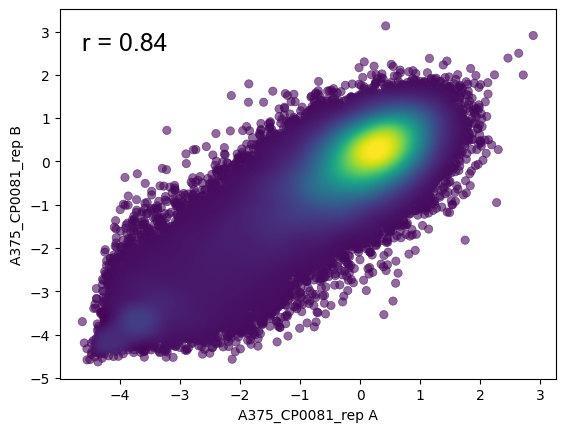

In [73]:
#checking replicate correlation for A375 data
gpplot.point_densityplot(data=lfc_df, x='A375_CP0081_rep A', y='A375_CP0081_rep B')
gpplot.add_correlation(data=lfc_df, x='A375_CP0081_rep A', y='A375_CP0081_rep B',fontsize=18)

<Axes: xlabel='A549_CP0081_rep A', ylabel='A549_CP0081_rep B'>

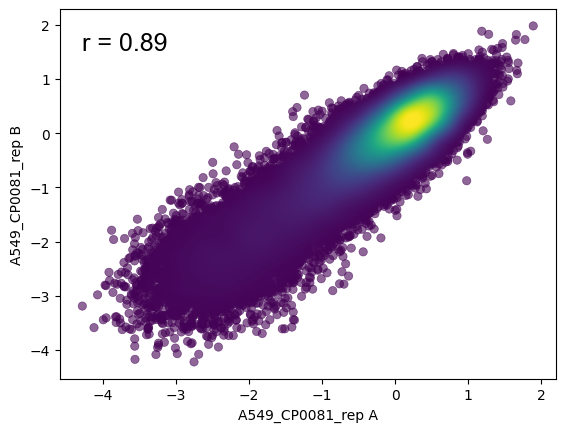

In [74]:
#repeating for A549 data
gpplot.point_densityplot(data=lfc_df, x='A549_CP0081_rep A', y='A549_CP0081_rep B')
gpplot.add_correlation(data=lfc_df, x='A549_CP0081_rep A', y='A549_CP0081_rep B',fontsize=18)

Now that we've confirmed that the replicates are adequately correlated for both conditions (r=0.84,0.89), replicates can be averaged

In [75]:
long_lfcs = (lfc_df.melt(id_vars=constructname_col,
                         var_name='condition', value_name='lfc'))

long_lfcs['condition'] = long_lfcs['condition'].map(condition_map)
lfcs_replicates_averaged = (long_lfcs.groupby([constructname_col, 'condition'])
            .agg(sgRNA_lfc = ('lfc', 'mean'))
            .reset_index())
lfcs_replicates_averaged.head()

,Construct Barcode,condition,sgRNA_lfc
0,AAAAAAGAAAGGATACGTCC,A375,0.015605
1,AAAAAAGAAAGGATACGTCC,A549,-0.001964
2,AAAAACAGCTGATGAAACCT,A375,-0.417453
3,AAAAACAGCTGATGAAACCT,A549,0.064261
4,AAAAACCTGGGAAAGATATA,A375,0.351430


At this point, we can merge the data with the guide mappings to understand which genes are targeting by each construct

In [76]:
annotated_sgrna_lfcs = guidemappings.merge(lfcs_replicates_averaged,how='inner',right_on=constructname_col,left_on=guidemappings_constructname_col)
if constructname_col != guidemappings_constructname_col:
    annotated_sgrna_lfcs=annotated_sgrna_lfcs.drop(guidemappings_constructname_col,axis=1)
annotated_sgrna_lfcs

,Target Gene Symbol,Construct Barcode,condition,sgRNA_lfc
0,A1BG,GTAGTGACCTCCATCCCCCA,A375,-2.842026
1,A1BG,GTAGTGACCTCCATCCCCCA,A549,-1.485838
2,A1BG,ACTGGCGCCATCGAGAGCCA,A375,0.408265
3,A1BG,ACTGGCGCCATCGAGAGCCA,A549,-0.225769
4,A1BG,GTGGAGTGGACTTCCAGCTA,A375,-0.421015
...,...,...,...,...
120735,NO_SITE,GAGCCGCCGAACGACGTATA,A549,0.688633
120736,NO_SITE,TCCCGCGACTCGCGATACAT,A375,0.847174
120737,NO_SITE,TCCCGCGACTCGCGATACAT,A549,1.231269
120738,NO_SITE,CCCGTATAACGGGTCGTCGC,A375,1.440758


### Z-score constructs to negative controls
We z-score the log fold change of each construct relative to negative controls to determine effect size. We recommend using intergenic-targeting constructs as negative controls; for CRISPRko constructs, this accounts for the slight viability effect of double-stranded breaks. The following code assumes that intergenic-targeting constructs have "INTERGENIC" in the corresponding target name

In [77]:
control_sgrna_lfcs = annotated_sgrna_lfcs[(annotated_sgrna_lfcs[guidemappings_targetname_col].str.count("INTERGENIC")>0)].reset_index(drop=True)
print("# negative control constructs per", control_sgrna_lfcs["condition"].value_counts())

# negative control constructs per condition
A375    900
A549    900
Name: count, dtype: int64


In [78]:
control_sgrna_stats = (control_sgrna_lfcs.groupby('condition')
                       .agg(neg_ctl_mean = ('sgRNA_lfc', 'mean'),
                            neg_ctl_sd = ('sgRNA_lfc', 'std'))
                       .reset_index())

zscored_sgrna_lfcs = annotated_sgrna_lfcs.copy()
zscored_sgrna_lfcs = (zscored_sgrna_lfcs.merge(control_sgrna_stats,
                                               how='inner', on='condition'))
zscored_sgrna_lfcs['z_scored_sgRNA_lfc'] = ((zscored_sgrna_lfcs['sgRNA_lfc'] - zscored_sgrna_lfcs['neg_ctl_mean'])/
                                          zscored_sgrna_lfcs['neg_ctl_sd'])
zscored_sgrna_lfcs = zscored_sgrna_lfcs.drop(['neg_ctl_sd', 'neg_ctl_mean','sgRNA_lfc'], axis=1)
zscored_sgrna_lfcs.head()

,Target Gene Symbol,Construct Barcode,condition,z_scored_sgRNA_lfc
0,A1BG,GTAGTGACCTCCATCCCCCA,A375,-5.147858
1,A1BG,GTAGTGACCTCCATCCCCCA,A549,-3.802060
2,A1BG,ACTGGCGCCATCGAGAGCCA,A375,0.489439
3,A1BG,ACTGGCGCCATCGAGAGCCA,A549,-0.801651
4,A1BG,GTGGAGTGGACTTCCAGCTA,A375,-0.948862


### Aggregate constructs on the gene level
To combine z-scores at the gene level, we sum the sgRNA z-scores and divide by the square root of the number of sgRNAs (Stouffer's method).

In [79]:
zscored_gene_lfcs = (zscored_sgrna_lfcs.groupby([guidemappings_targetname_col, 'condition'])
                     .agg(z_scored_lfc_sum = ('z_scored_sgRNA_lfc', 'sum'),
                          n_sgrnas = ('z_scored_sgRNA_lfc', 'count'))
                     .reset_index())
zscored_gene_lfcs['genelevel_zscore'] = (zscored_gene_lfcs['z_scored_lfc_sum']/np.sqrt(zscored_gene_lfcs['n_sgrnas']))
zscored_gene_lfcs = zscored_gene_lfcs.drop('z_scored_lfc_sum', axis=1)
zscored_gene_lfcs.head()

,Target Gene Symbol,condition,n_sgrnas,genelevel_zscore
0,A1BG,A375,3,-3.237366
1,A1BG,A549,3,-3.747092
2,A1CF,A375,3,2.102259
3,A1CF,A549,3,-0.304819
4,A2M,A375,3,0.292943


We filter out genes that are only targeted by 1 sgRNA after processing; any hit genes should have more than one sgRNA as evidence

In [80]:
zscored_gene_lfcs=zscored_gene_lfcs[zscored_gene_lfcs["n_sgrnas"]>1].reset_index(drop=True)

We then construct an empirical null distribution of gene-level z-scores by grouping control constructs into pseudogenes and calculating a (pseudo)gene-level z-score. Pseudogenes are constructed by sampling with replacement to ensure that this approach is still effective with small control set sizes. The empirical p-value for a gene-level z-score is the % of the pseudogene distribution that is below or above that value (whichever is smaller).

In [81]:
#randomly sample controls to create pseudogenes, calculate aggregate z-score for each pseudogene
def get_pseudogene_distribution(df_with_guide_zscores,df_with_gene_zscores):
    #get guide-level z-scores of controls
    control_zscores= df_with_guide_zscores[df_with_guide_zscores[guidemappings_targetname_col].isin(control_sgrna_lfcs[guidemappings_targetname_col].tolist())].reset_index(drop=True)

    #num guides in each pseudogene is average num guides per gene in screen 
    num_guides_per_pseudogene= round(df_with_gene_zscores["n_sgrnas"].mean())
    
    random.seed(0)
    num_pseudogenes=1000
    control_pseudogene_zscores=[]
    for i in range(num_pseudogenes):
        #select n random indices from the list of control guides (n being the number of guides in a pseudogene)
        #sampling with replacement enables a more representative distribution, beneficial for small control set size
        control_guides_in_pseudogene=random.choices(range(len(control_zscores)), k=num_guides_per_pseudogene)
        control_pseudogene= control_zscores.loc[control_guides_in_pseudogene,:]
        #implements stouffers to calculate pseudogene-level z-score from z-score of each guide in pseudogene 
        control_pseudogene_zscores.append( control_pseudogene["z_scored_sgRNA_lfc"].sum()/np.sqrt(num_guides_per_pseudogene))
    control_pseudogene_zscores.sort()
    return control_pseudogene_zscores

#calculate control pseudogene distribution separately for each condition
control_pseudogene_zscore_distribution_map={}
for condition in zscored_gene_lfcs["condition"].unique():
    control_pseudogene_zscore_distribution_map[condition]= get_pseudogene_distribution(zscored_sgrna_lfcs[zscored_sgrna_lfcs["condition"]==condition].reset_index(),zscored_gene_lfcs[zscored_gene_lfcs["condition"]==condition].reset_index())

def get_empirical_gene_pval(gene_level_z_score,condition):
    #use the control distribution that corresponds to the condition that the gene-level z-score is calculated from
    control_pseudogene_zscores= control_pseudogene_zscore_distribution_map[condition]
    #estimate probability distribution of pseudogene z-scores to get AUC for pval
    kde= scipy.stats.gaussian_kde(control_pseudogene_zscores)
    ha_less=kde.integrate_box_1d(-np.inf, gene_level_z_score)
    ha_greater=kde.integrate_box_1d(gene_level_z_score, np.inf)
    strongest_p_val=np.min([ha_less,ha_greater])
    return strongest_p_val

zscored_gene_lfcs['pval'] = zscored_gene_lfcs.apply(lambda x: get_empirical_gene_pval(x.genelevel_zscore,x.condition),axis=1)
zscored_gene_lfcs.head()

,Target Gene Symbol,condition,n_sgrnas,genelevel_zscore,pval
0,A1BG,A375,3,-3.237366,0.005412
1,A1BG,A549,3,-3.747092,0.003001
2,A1CF,A375,3,2.102259,0.005942
3,A1CF,A549,3,-0.304819,0.374912
4,A2M,A375,3,0.292943,0.393810


Lastly, to account for multiple testing, we calculate a false discovery rate for each gene with a Benjamini-Hochberg correction.

In [82]:
zscored_gene_lfcs=zscored_gene_lfcs.sort_values(by="condition")
zscored_gene_lfcs_agg_by_condition=zscored_gene_lfcs.groupby("condition").agg(list).reset_index()
zscored_gene_lfcs_agg_by_condition["FDR"]=zscored_gene_lfcs_agg_by_condition["pval"].apply(lambda x: multipletests(x,method="fdr_bh")[1])
zscored_gene_lfcs["FDR"]= zscored_gene_lfcs_agg_by_condition["FDR"].explode().tolist()

Uncomment (remove #) to save the results for each condition as a csv file. The false discovery rate indicates the probability of the target phenotype (considering evidence from each individual guide) occuring by random chance. 

In [83]:
#zscored_gene_lfcs[zscored_gene_lfcs["condition"]=="A549"][["Target Gene Symbol","genelevel_zscore","FDR"]].to_csv("A549_results.csv",index=False)
#zscored_gene_lfcs[zscored_gene_lfcs["condition"]=="A375"][["Target Gene Symbol","genelevel_zscore","FDR"]].to_csv("A375_results.csv",index=False)
